## Imports

In [1]:
import sys, os, time
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import numpy as np
import jax
import jax.numpy as jnp
import torch
import h5py

sys.path.insert(0, '../jaxtpc')
sys.path.insert(0, '..')
from tools.geometry import generate_detector
from tools.simulation import DetectorSimulator
from tools.loader import load_event

from goop import OpticalSimConfig, OpticalSimulator, write_config_light, save_event_light
from goop.kernels import SERKernel
from goop.delays import ScintillationBiexponentialDelay, TTSDelay, TPBTriexponentialDelay
from goop.digitize import DigitizationConfig
from goop.sampler import create_default_tof_sampler

## Config

In [2]:
DATA_PATH = '/sdf/home/y/youngsam/sw/dune/sirentv/data/out.h5'
CONFIG_PATH = '../jaxtpc/config/cubic_wireplane_config.yaml'
OUTPUT_PATH = '../data/light_output_ancestor.h5'
N_SAVE = 100
TOTAL_PAD = 250_000
RESPONSE_CHUNK_SIZE = 50_000
SAVE_INTERACTIONS = False
SAVE_ANCESTOR_TRACK_IDS = True

N_BITS = 15
ADC_MAX = (1 << N_BITS) - 1
PEDESTAL = 0.9 * ADC_MAX
MAX_PE_PER_PMT = 90_000
LABEL_BATCH_SIZE = 16  # max labels per virtual-channel batch (None = all at once)

## Initialize JAXTPC config & GOOP simulator

Note that JAXTPC has been modified to expose per-volume interaction IDs, see [../data/jaxtpc_interaction_ids.patch](../data/jaxtpc_interaction_ids.patch)

In [3]:
# jaxtpc detector + simulator
detector_config = generate_detector(CONFIG_PATH)
sim = DetectorSimulator(detector_config, total_pad=TOTAL_PAD,
                        response_chunk_size=RESPONSE_CHUNK_SIZE, include_track_hits=False)
cfg = sim.config

# JIT warm-up
deposits = load_event(DATA_PATH, cfg, event_idx=0)
filled = sim.process_event_light(deposits)
jax.block_until_ready(filled.volumes[0].charge)
print(f'JIT done. {cfg.n_volumes} volume(s).')

# GOOP simulator
goop_config = OpticalSimConfig(
    tof_sampler=create_default_tof_sampler(lazy=False),
    delays=[ScintillationBiexponentialDelay(singlet_fraction=0.3, tau_singlet_ns=6.0, tau_triplet_ns=1300.0),
            TPBTriexponentialDelay(), TTSDelay(fwhm_ns=2.4, apply_transit_time=True)],
    tick_ns=1.0,
    kernel=SERKernel(device=torch.device('cuda'), duration_ns=10_000),
    gain=2**N_BITS / MAX_PE_PER_PMT,
    oversample=10,
    ser_jitter_std=0.1,
    baseline_noise_std=2.6,
    digitization=DigitizationConfig(n_bits=N_BITS, pedestal=PEDESTAL),
)
goop_sim = OpticalSimulator(goop_config)
print(f'GOOP ready: {N_BITS}-bit ADC, pedestal={PEDESTAL:.0f}, {goop_config.n_channels} channels')

--- Creating DetectorSimulator ---
   Extracting parameters...


E0402 14:03:51.276091  173772 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0402 14:03:51.276201  173773 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0402 14:03:51.276234  173774 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=250,000, response_chunk=50,000, num_s=16, K_wire=2, K_time=6
   Track labeling: DISABLED
   Volumes: 2
--- DetectorSimulator Ready ---
JIT done. 2 volume(s).
GOOP ready: 15-bit ADC, pedestal=29490, 162 channels


## Simulate & save 100 events

In [4]:
label_key = "ancestor"
with h5py.File(OUTPUT_PATH, 'w') as f:
    write_config_light(f, goop_config, label_key=label_key, n_labels=cfg.n_volumes,
                       source_file=DATA_PATH, n_events=N_SAVE)

    print(f"{'Evt':>4} {'Segs':>8} {'Photons':>12} {'PEs':>10} {'Chunks':>7} {'t(s)':>6}")
    print('-' * 60)

    for evt in range(N_SAVE):
        deposits = load_event(DATA_PATH, cfg, event_idx=evt)
        res = sim.process_event_light(deposits)
        jax.block_until_ready(res.volumes[0].charge)

        all_pos, all_nph, all_t, all_labels = [], [], [], []
        for v in range(cfg.n_volumes):
            vol = res.volumes[v]
            n = vol.n_actual
            if n == 0:
                continue
            all_pos.append(vol.positions_mm[:n])
            all_nph.append(jnp.ceil(vol.photons[:n]).astype(jnp.int32))
            all_t.append(vol.t0_us[:n] * 1000.0)
            if SAVE_INTERACTIONS:
                all_labels.append(vol.interaction_ids[:n])
            elif SAVE_ANCESTOR_TRACK_IDS:
                all_labels.append(vol.ancestor_track_ids[:n])
            else:
                all_labels.append(jnp.full((n,), v, dtype=jnp.int32))

        pos_mm = jnp.concatenate(all_pos)
        n_ph = jnp.concatenate(all_nph)
        t_ns = jnp.concatenate(all_t)
        labels = jnp.concatenate(all_labels)

        t0 = time.time()
        waveforms = goop_sim.simulate(pos_mm, n_ph, t_ns,
                                      labels=labels, stitched=True,
                                      subtract_t0=False, add_baseline_noise=False,
                                      label_batch_size=LABEL_BATCH_SIZE)
        elapsed = time.time() - t0

        save_event_light(f, f'event_{evt:03d}', waveforms,
                         source_event_idx=evt, digitized=True, n_bits=N_BITS)

        total_pe = sum(w.attrs['pe_counts'].sum().item() for w in waveforms)
        total_chunks = sum(w.n_chunks for w in waveforms)
        print(f'{evt:>4} {pos_mm.shape[0]:>8,} {int(n_ph.sum()):>12,} '
              f'{total_pe:>10,} {total_chunks:>7,} {elapsed:>5.2f}s')
        del waveforms

print('-' * 60)
print(f'Saved {N_SAVE} events to {OUTPUT_PATH}')

 Evt     Segs      Photons        PEs  Chunks   t(s)
------------------------------------------------------------
   0  226,796  371,059,868  1,657,784   8,991  6.86s
   1  263,503  407,046,307  1,988,707   9,518  5.54s
   2   94,886  137,520,911    685,586   3,015  1.83s
   3  209,010  313,502,764  1,399,357   7,170  4.57s
   4   98,513  181,166,077    911,421   3,801  2.15s
   5  220,704  395,567,305  1,928,418   8,664  5.20s
   6  151,408  220,567,945    977,832   5,335  3.23s
   7  171,890  304,734,259  1,490,094   9,310  5.47s
   8  150,203  223,211,791  1,159,095   4,170  2.54s
   9  178,142  313,496,343  1,529,989  10,143  5.86s
  10  360,100  598,299,716  2,842,743  12,180  7.47s
  11  234,300  391,362,169  1,678,157   9,676  5.89s
  12   89,508  150,089,086    696,534   4,502  2.70s
  13  141,998  231,739,587  1,003,979   4,834  2.99s
  14  240,501  354,046,099  1,870,428   6,816  4.03s
  15  258,454  450,765,559  2,105,158  10,522  6.51s
  16  208,069  323,135,039  1,586,755 

In [5]:
import os
from goop.io import load_event_light

fsize = os.path.getsize(OUTPUT_PATH)
print(f'File size: {fsize / 1e6:.1f} MB ({fsize / N_SAVE / 1e6:.1f} MB/event)')

with h5py.File(OUTPUT_PATH, 'r') as f:
    print(f'Config: label_key={f["config"].attrs["label_key"]}, n_labels={f["config"].attrs["n_labels"]}, '
          f'baseline_noise_std={f["config"].attrs["baseline_noise_std"]}')
    wfs = load_event_light(f, 'event_000', device='cpu')
    label_key = f['config'].attrs['label_key'].capitalize()
    for v, wf in enumerate(wfs):
        print(f'  {label_key} {v}: {wf.n_chunks} chunks, {wf.adc.numel():,} samples, '
              f'PE={wf.attrs["pe_counts"].sum().item():,}')

File size: 1221.5 MB (12.2 MB/event)
Config: label_key=ancestor, n_labels=2, baseline_noise_std=2.6
  Ancestor 0: 170 chunks, 3,430,090 samples, PE=32,496
  Ancestor 1: 169 chunks, 3,016,174 samples, PE=40,137
  Ancestor 2: 173 chunks, 3,774,741 samples, PE=72,254
  Ancestor 3: 166 chunks, 2,673,252 samples, PE=18,110
  Ancestor 4: 165 chunks, 2,528,461 samples, PE=8,577
  Ancestor 5: 165 chunks, 2,419,143 samples, PE=5,223
  Ancestor 6: 168 chunks, 2,599,913 samples, PE=8,336
  Ancestor 7: 166 chunks, 2,878,174 samples, PE=44,918
  Ancestor 8: 164 chunks, 3,524,402 samples, PE=70,136
  Ancestor 9: 166 chunks, 3,399,904 samples, PE=105,387
  Ancestor 10: 168 chunks, 3,061,176 samples, PE=14,793
  Ancestor 11: 165 chunks, 2,672,988 samples, PE=19,447
  Ancestor 12: 168 chunks, 3,252,373 samples, PE=22,947
  Ancestor 13: 163 chunks, 2,575,646 samples, PE=18,048
  Ancestor 14: 165 chunks, 2,793,080 samples, PE=30,497
  Ancestor 15: 167 chunks, 2,863,371 samples, PE=28,245
  Ancestor 16: 1

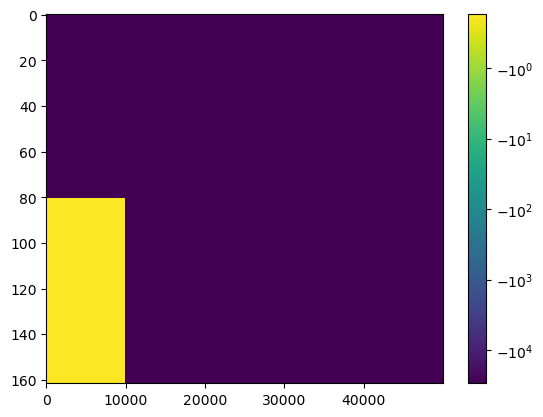

In [6]:
wf0 = wfs[1]

wf0d = wf0.deslice()
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

plt.imshow(
    wf0d.adc[:, :50000] - goop_sim.config.digitization.pedestal,
    aspect='auto',
    interpolation='none',
    norm=SymLogNorm(linthresh=1, linscale=1, vmin=None, vmax=None, base=10)
)
plt.colorbar()
plt.show()


In [8]:
torch.unique(wf0d.adc[:, :50000])

tensor([    0., 29490.])